## Mapping CU **Boulder** (East Campus) with OpenStreetMap and Python

![https://seec.colorado.edu/assets/seec_landscape.jpeg](https://seec.colorado.edu/assets/seec_landscape.jpeg)

In this notebook, we will use **OpenStreetMap (OSM)** data and Python to create a map of **East Campus at the University of Colorado Boulder**.

OpenStreetMap is a global, community-built map database that includes information about roads, buildings, water features, boundaries, parks, and many other types of geographic features. Using Python, we can search for a place, download spatial data from OSM, and create maps that help us better understand the built and natural environment around that location.

During the demo, we will walk through a workflow that shows how to:

- Search for a place using OSM
- Download geographic features such as buildings, roads, water, and boundaries
- Store those features as GeoDataFrames
- Create a map using Python
- Customize the map to make different features easier to see

We will begin by mapping **CU Boulder’s East Campus** as an example. After the demo, you will have time to repeat the workflow for a campus, neighborhood, town, park, or other place of your choosing.

By the end of this activity, you should have a basic understanding of how Python can be used to access open geographic data and create maps for exploring real places.

In [ ]:
# Uncomment this cell if running notebook in Google Colab
#!pip install osmnx hvplot geoviews

## Import Python Libraries

Before we begin mapping, we need to import the Python libraries that will help us download, organize, and visualize spatial data.

This notebook uses several different libraries:

- **osmnx** is used to search for and download data from OpenStreetMap.
- **geopandas** is used to work with spatial data in Python.
- **matplotlib** is used to create static plots and maps.
- **hvplot** is used to create interactive maps.

The code below imports the libraries we will use throughout the notebook.

In [2]:
# Import python libraries
import osmnx as osm
import geopandas as gpd
import matplotlib.pyplot as plt
import hvplot.pandas
import geoviews
import holoviews as hv

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


## Search for a Place with `geocode_to_gdf()`

Next, we will search for **University of Colorado Boulder** using the `geocode_to_gdf()` function from `osmnx`.

This function sends a place name to OpenStreetMap and returns the result as a **GeoDataFrame**. A GeoDataFrame is similar to a regular pandas DataFrame, but it includes a special `geometry` column that stores spatial information such as points, lines, or polygons.

In this example, we are asking OSM to find the boundary or location associated with **University of Colorado Boulder**.

The output will show the OpenStreetMap search result in table form. Important columns may include the place name, type of feature, OpenStreetMap ID, bounding box information, and geometry.

We will use this GeoDataFrame as the starting point for mapping CU Boulder.

In [3]:
# Look for CU Boulder using geocode_to_gdf
cu_gdf = osm.geocode_to_gdf("Agnes Scott College")
cu_gdf

TypeError: Nominatim could not geocode query 'Agnes Scott College' to a geometry of type (Multi)Polygon

## Plot the CU Boulder Boundary

Now that we have a GeoDataFrame for **University of Colorado Boulder**, we can create a quick plot of the geometry.

This first map is a simple, static plot. It gives us a quick way to check whether the data we downloaded from OpenStreetMap looks reasonable.

At this stage, the map may look very simple. That is okay. The goal is to confirm that Python found a spatial feature for CU Boulder and that the geometry can be plotted.

Later, we will add more geographic features, such as buildings, roads, and water, to create a more detailed map.

<Axes: >

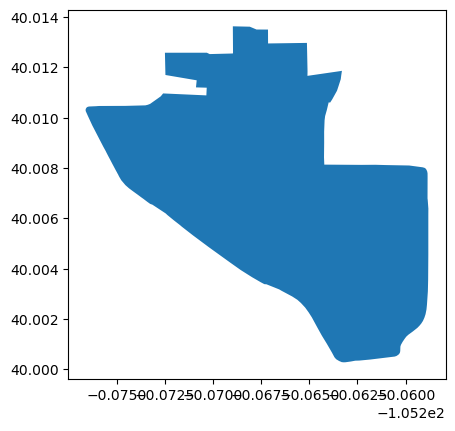

In [6]:
# Plot the boundary
cu_gdf.plot()

## Search for OSM Features Near an Address

There are multiple ways to search for data in OpenStreetMap. In the previous example, we used `geocode_to_gdf()` to search for a place boundary. Another approach is to search for **specific types of features** near a location.

In this example, we are using `features_from_address()` to search within **1,000 meters** of an address for features tagged as a university.

OSM data are organized using **tags**, which describe what a feature is. Tags are often written as key-value pairs. Here, we are searching for features where:

- the key is `amenity`
- the value is `university`

This means we are asking OpenStreetMap to return nearby features that are labeled as universities.

The `dist=1000` argument controls the search distance. In this case, Python will search for matching OSM features within 1,000 meters of the address.

The output is a GeoDataFrame containing the matching OSM features. This can be useful when you want to search for a category of features near a location rather than only searching for one named place.

In [9]:
# Look for everything labeled 'University' within 1000m of an address
uni = osm.features_from_address(
    'Boulder, Colorado, USA',
    {'amenity': ['university']},
    dist=2000) # adjust dist= to find more buildings
uni

geometry  \
element_type osmid                                                          
way          46226108   POLYGON ((-105.27589 40.01047, -105.27597 40.0...   
             76453704   POLYGON ((-105.25317 40.01365, -105.25365 40.0...   
             203508769  POLYGON ((-105.24734 39.99889, -105.24733 39.9...   
             203508770  POLYGON ((-105.24815 40.01829, -105.24816 40.0...   
             391232001  POLYGON ((-105.26632 40.01452, -105.26631 40.0...   

                                                                    nodes  \
element_type osmid                                                          
way          46226108   [589514700, 2188984094, 2188984095, 326889012,...   
             76453704   [901426436, 1880367757, 1880367753, 1880367751...   
             203508769  [393014367, 393014366, 393014365, 393014364, 1...   
             203508770  [2135228023, 2135228020, 2135228019, 213522801...   
             391232001  [3944423259, 3944423260, 3944423261, 394442326...   

                           amenity        boundary internet_access  \
element_type osmid                                                   
way          46226108   university  administrative            wlan   
             76453704   university  administrative             NaN   
             203508769  university  administrative             NaN   
             203508770  university  administrative             NaN   
             391232001  university             NaN             NaN   

                                                                     name  \
element_type osmid                                                          
way          46226108        University of Colorado Boulder (Main Campus)   
             76453704        University of Colorado Boulder (East Campus)   
             203508769  University of Colorado Boulder (Williams Village)   
             203508770              University of Colorado Boulder (CINC)   
             391232001                                  Naropa University   

                                              operator  short_name  \
element_type osmid                                                   
way          46226108   University of Colorado Boulder  CU Boulder   
             76453704   University of Colorado Boulder         NaN   
             203508769  University of Colorado Boulder         NaN   
             203508770  University of Colorado Boulder         NaN   
             391232001               Naropa University         NaN   

                                          website  wikidata  \
element_type osmid                                            
way          46226108   https://www.colorado.edu/   Q736674   
             76453704                         NaN       NaN   
             203508769                        NaN       NaN   
             203508770                        NaN       NaN   
             391232001     https://www.naropa.edu  Q2975783   

                                                wikipedia  check_date  \
element_type osmid                                                      
way          46226108   en:University of Colorado Boulder         NaN   
             76453704                                 NaN  2024-05-06   
             203508769                                NaN         NaN   
             203508770                                NaN         NaN   
             391232001               en:Naropa University         NaN   

                         loc_name   ele gnis:feature_id  
element_type osmid                                       
way          46226108         NaN   NaN             NaN  
             76453704         NaN   NaN             NaN  
             203508769  Will Vill   NaN             NaN  
             203508770        NaN   NaN             NaN  
             391232001        NaN  1620          178660

## Find East Campus

Now that we have seen a couple of ways to query OpenStreetMap, we will focus on one specific area for the rest of the demonstration: **CU Boulder East Campus**.

Rather than running a new OSM search, we will use the results from the earlier `features_from_address()` query and select the row that represents East Campus. 

In this step, we search within the existing `boulder_uni` GeoDataFrame for the East Campus feature and save the result as a new GeoDataFrame called `east_campus`.

We will use `east_campus` as the main boundary for the rest of the mapping workflow. Starting with a defined study area helps us find, clip, and plot other map layers, such as buildings, roads, water features, and other geographic data.

We also plot the East Campus boundary to check that we selected the correct feature before moving on.

In [13]:
# Find University of Colorado (East Campus)
east_campus = osm.features_from_address("University of Colorado Boulder (East Campus)", {'amenity': ['university']})
east_campus

geometry  \
element_type osmid                                                          
way          76453704   POLYGON ((-105.25317 40.01365, -105.25365 40.0...   
             203508770  POLYGON ((-105.24815 40.01829, -105.24816 40.0...   

                                                                    nodes  \
element_type osmid                                                          
way          76453704   [901426436, 1880367757, 1880367753, 1880367751...   
             203508770  [2135228023, 2135228020, 2135228019, 213522801...   

                           amenity        boundary  \
element_type osmid                                   
way          76453704   university  administrative   
             203508770  university  administrative   

                                                                name  \
element_type osmid                                                     
way          76453704   University of Colorado Boulder (East Campus)   
             203508770         University of Colorado Boulder (CINC)   

                                              operator  check_date  
element_type osmid                                                  
way          76453704   University of Colorado Boulder  2024-05-06  
             203508770  University of Colorado Boulder         NaN

<Axes: >

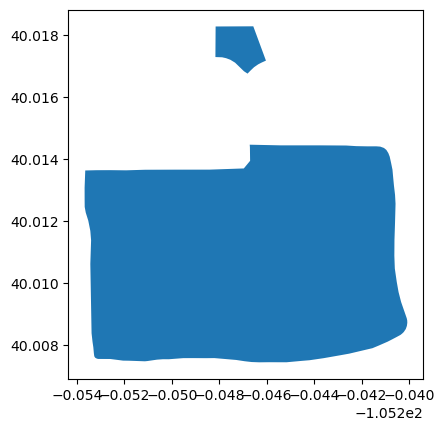

In [14]:
# Plot the data
east_campus.plot()

## Extract the East Campus Polygon

The `east_campus` GeoDataFrame includes a `geometry` column that stores the spatial shape returned from OpenStreetMap.

In this step, we extract the first geometry from that GeoDataFrame and save it as a variable called `polygon`.

Because our OSM search returned the boundary of East Campus, this geometry should be a **polygon**. A polygon is a closed shape that represents an area, such as a campus boundary, park, lake, or neighborhood.

We will use this polygon to define our study area. Later, it can help us find or clip other OSM features so that our map focuses on East Campus rather than the surrounding area.

In [ ]:
# Extract ploygon from geometry
polygon = ____.geometry.iloc[0]
polygon

## Find Buildings Within the East Campus Boundary

Now that we have extracted the East Campus polygon, we can use it to search for features **inside that boundary**.

In this step, we use `features_from_polygon()` to find all OpenStreetMap features within the East Campus polygon that have a `building` tag.

The tag:

`{"building": True}`

means that we are asking OpenStreetMap to return any feature that is labeled as a building, regardless of the specific building type. This may include classrooms, labs, offices, residence buildings, garages, and other structures.

The result is stored as a GeoDataFrame called `buildings`. Each row represents a building feature returned from OSM, and the `geometry` column stores the shape of that building.

This layer will help us add more detail to our East Campus map.

In [ ]:
# Get buildings with the polygon using features_from_polygon()


In [ ]:
# Plot the buildings


In [ ]:
# BONUS - Select the SEEC building from the buildings geodataframe


In [ ]:
# BONUS - Select the SEEC building from the buildings geodataframe (again)


In [ ]:
# Plot SEEC


## Find Roads Within the East Campus Boundary

Next, we will use the same East Campus polygon to search for roads and paths within the study area.

In OpenStreetMap, roads, streets, sidewalks, paths, and other travel routes are commonly stored using the `highway` tag. Even though the word “highway” may sound like it only refers to major roads, in OSM it is used more broadly to describe many types of transportation features.

The tag:

`{"highway": True}`

asks OpenStreetMap to return any feature inside the East Campus polygon that has a `highway` tag.

The result is stored as a GeoDataFrame called `roads`. Depending on what is available in OSM, this layer may include streets, service roads, bike paths, footpaths, sidewalks, or other transportation features.

Adding roads to the map will help provide context and make it easier to understand how buildings and other features are arranged across East Campus.

In [ ]:
# Get roads
roads = osm.features_from_polygon(____,
                                      tags={"____": ____})
roads

## Plot Roads and the Campus Boundary Together

Before adding more layers, it is useful to make a quick plot to check how our data line up.

In this step, we plot the **roads** layer and the **East Campus boundary** on the same map. This helps us see whether the roads returned from OpenStreetMap fall within the study area and whether the boundary looks reasonable.

This is an important part of working with spatial data. As we add and modify layers, we will repeatedly make quick plots to check our work. These checks help us catch problems early, such as missing data, unexpected geometries, or features that extend beyond our area of interest.

The East Campus boundary is plotted with no fill color and a black outline so that we can see the roads underneath it.

In [ ]:
# Plot roads and boundary together 
fig, ax = plt.subplots(figsize=(10,10))
_____.plot(ax=ax)
_____.plot(ax=ax, color='_____', edgecolor='_____')

## Clip Roads to the Campus Boundary

When we plotted the roads and East Campus boundary together, we noticed that some road features extended beyond the campus boundary.

This happens because OpenStreetMap features are not always neatly divided at the edge of our study area. A road may pass through East Campus but continue beyond the boundary, so OSM returns the full road segment rather than only the portion inside the campus.

To focus our map on East Campus, we can **clip** the roads layer to the campus boundary.

Clipping is a common spatial operation that trims one layer using the shape of another layer. In this case, we are using the East Campus boundary as a “cookie cutter” to keep only the parts of the roads that fall inside the boundary.

The result is a new GeoDataFrame called `roads_clipped`, which contains only the road features within East Campus.

In [ ]:
# Clip roads to campus boundary
roads_clipped = gpd.clip(
    _____,
    _____
)

roads_clipped

## Check the Clipped Roads Layer

After clipping the roads to the East Campus boundary, we should plot the data again to check the result.

This map shows the **clipped roads** and the **East Campus boundary** together. The goal is to confirm that the roads now stay within the campus boundary instead of extending beyond it.

This kind of visual check is an important part of spatial data wrangling. Each time we modify a layer, we want to quickly inspect the output before moving on. This helps us make sure the data are behaving the way we expect.

If the clipping worked correctly, the road features should now be limited to the area inside the East Campus boundary.

In [ ]:
# Plot clipped roads and boundary together 
fig, ax = plt.subplots(figsize=(10,10))
_____.plot(ax=ax)
_____.plot(ax=ax, color='None', edgecolor='black')

## Keep Only Road Line Features

Later in the notebook, we will create an **interactive map** with multiple layers. For interactive plotting, each layer works best when it contains only one type of geometry.

The clipped roads layer may include more than one geometry type. For example, it may contain:

- **LineString** features, which represent individual road or path lines
- **MultiLineString** features, which represent road or path features made up of multiple connected line segments
- **Point** features, sometimes called nodes, which represent individual locations

Because roads are best represented as lines on a map, we will create a new GeoDataFrame that keeps only the `LineString` and `MultiLineString` geometries.

The result is saved as `road_lines`. This cleaned-up layer will be easier to use when we build the final interactive map.

In [ ]:
# Keep only linestring for interactive plotting
road_lines = _____[
    _____.geometry.type.isin(["_____", "_____"])]
road_lines

## Find Water Features Within the East Campus Boundary

Next, we will repeat the same general workflow we used for roads, but this time we will search for **water features** within the East Campus boundary.

OpenStreetMap stores water-related features using several different tags. In this example, we search for features that may be labeled as natural water, waterways, or other water features.

These tags can return features such as ponds, streams, drainage channels, ditches, or other mapped water-related areas, depending on what is available in OSM for the study area.

The result is stored as a GeoDataFrame called `water`. Each row represents a water-related feature returned from OpenStreetMap, and the `geometry` column stores its spatial shape.

Adding water features will make our campus map more complete and help show how built infrastructure, roads, and natural or semi-natural features fit together across East Campus.

In [ ]:
# Get water
water = osm.features_from_polygon(polygon,
                                      tags={"_____":"_____",
                                            "_____": _____,
                                            "_____":_____})
water

## Plot Water Features and the Campus Boundary

After downloading the water features, we will plot them with the East Campus boundary to check how the layer looks.

This quick plot helps us see whether the water features returned from OpenStreetMap are located within or near the East Campus study area. As with the roads layer, some features may extend beyond the boundary depending on how they are stored in OSM.

This visual check helps us decide whether the water layer needs additional cleaning, such as clipping to the campus boundary or filtering by geometry type.

The East Campus boundary is plotted with no fill color and a black outline so that we can see how the water features line up with the study area.

In [ ]:
# Plot water and boundary together 
fig, ax = plt.subplots(figsize=(10,10))
_____.plot(ax=ax)
_____.plot(ax=ax, color='None', edgecolor='black')

## Clip Water Features to the Campus Boundary

Just like we did with the roads layer, we can clip the water features to the East Campus boundary.

Some water features may extend beyond our study area because OpenStreetMap stores them as larger connected features. For example, a stream, drainage channel, or pond edge may continue outside the campus boundary even if only part of it passes through East Campus.

Clipping trims the water layer so that only the portions inside the East Campus boundary are kept.

The result is saved as `water_clipped`. This cleaned-up layer will help keep the final map focused on the East Campus study area.

In [ ]:
# Clip water lines to campus boundary
water_clipped = gpd.clip(
    _____,
    _____
)

water_clipped


In [ ]:
# Plot water and boundary together 
fig, ax = plt.subplots(figsize=(10,10))
_____.plot(ax=ax)
_____.plot(ax=ax, color='None', edgecolor='black')

## Separate Water Features by Geometry Type

Before making the final interactive map, we will separate the clipped water features by geometry type.

Water features in OpenStreetMap can be represented in different ways. For example:

- **Polygon** or **MultiPolygon** features may represent areas of water, such as ponds, lakes, or reservoirs.
- **LineString** or **MultiLineString** features may represent linear water features, such as streams, ditches, or drainage channels.

Interactive maps often work best when each layer contains only one type of geometry. To make plotting easier, we will create two separate GeoDataFrames:

- `water_polygons` for area-based water features
- `water_lines` for line-based water features

This gives us more control over how each type of water feature appears on the final map.

In [ ]:
# Splitting water into lines and polygons for easier plotting
water_polygons = _____[
    _____.geometry.geom_type.isin(
        ["_____", "_____"])]

water_polygons


water_lines = _____[
    _____.geometry.geom_type.isin(
        ["_____", "_____"])]

water_lines


## Create a Static Map with All Layers

Now that we have downloaded and cleaned several OpenStreetMap layers, we can plot them together on one map.

This static map includes:

- the **East Campus boundary**
- **buildings**
- **roads and paths**
- **water features**

Plotting all of the layers together allows us to see how the different features relate to one another across the campus. Buildings provide structure, roads and paths show movement through the area, and water features add environmental context.

This map is still a static image, but it is an important checkpoint before creating the final interactive version. It lets us confirm that the layers overlap correctly and that the map includes the main features we want to show.

The map title describes the place being mapped and identifies OpenStreetMap as the data source.

In [ ]:
# Plot all layers together on a single axis
fig, ax = plt.subplots(figsize=(10, 10))

# Plot East Campus boundary
_____.plot(
    ax=ax,
    color="None",
    linewidth=2
)

# Plot buildings


# Plot roads


# Plot water


# Plot SEEC



ax.set_title("_____")
ax.set_axis_off()

plt.show()

In [ ]:
# Create an interactive map using hvplot

# Map buildings
buildings_map = _____.hvplot(
    geo=True,
    tiles="OSM",
    fill_color="yellow",
    line_color="black",
    alpha=1.0,
    line_width=2,
    height=600,
    width=800,
    title="_____"
)

# Map East Campus boundary
east_campus_map = _____.hvplot(
    geo=True,
    fill_color="yellow",
    line_color="black",
    fill_alpha=0.3,
    line_width=5
)

# Plot water lines (creeks)
creek_map = _____.hvplot(
    geo=True,
    line_color="blue",
    line_width=4
)

# Plot water polygons (ponds, lakes)


# Plot roads


# Plot SEEC




east_campus_map = buildings_map * east_campus_map * creek_map * _____ * _____ * _____

# Save the map as a file to put on the web (OPTIONAL)
hv.save(east_campus_map, 'east_campus_map.html')

east_campus_map